# Full delegation analysis

**Delegation as an outcome, not just a control (H2 mechanism).** The leader decides
whether to delegate to the three expert reviewers (`clarity`, `experiments`, `impact`)
or write the review alone. That decision is parsed straight from each run's
`trace.jsonl` — there is no `delegation.json`, so this notebook reads the traces under
`eval/reviews/full/` directly.

Per run we extract:
- **coverage** — number of distinct expert roles that returned a `delegation_finished`
  record (0–3). Matches `RunArtifacts.has_role_output`, i.e. the experts that actually
  fed the downstream substance metrics.
- **footer_delegations** — raw delegation-call count from `run_footer` (can exceed
  coverage when the leader re-delegates to the same role).
- **errors** — `delegation_error` records.

Sections: (1) delegation by leader model, (2) coverage by config, (3) paper-dependence,
(4) does delegating track win-rate? Capability is confounded with the leader's
delegation habit, so treat §4 as descriptive — see the caveats in §5.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_SET = "full"

# Walk up until we find eval/ so the notebook runs regardless of CWD.
ROOT = Path.cwd()
while not (ROOT / "eval").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

REVIEWS_DIR = ROOT / "eval" / "reviews" / RUN_SET
RESULTS_DIR = ROOT / "eval" / "results" / RUN_SET
BATCHES = ROOT / "eval" / "batches.json"
FIG_DIR = ROOT / "eval" / "analysis" / "figures" / RUN_SET
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- palette (seaborn deep quad) ---
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
MODEL_COLORS = {"A": PALETTE[0], "B": PALETTE[1], "C": PALETTE[2]}
MODEL_NAMES = {"A": "qwen3-32b", "B": "mistral-small-3.2", "C": "llama-3.3-70b"}
ROLE_COLORS = dict(zip(
    ("leader", "clarity", "experiments", "impact"), PALETTE
))
ROLES = ("leader", "clarity", "experiments", "impact")
C_HET, C_REF = PALETTE[0], PALETTE[1]  # blue het, orange ref
C_ANNOT, C_MUTED, C_REF_LINE, C_EDGE, C_ERR = (
    "#333333", "#555555", "#666666", "#FFFFFF", "#333333",
)
# --- layout constants (fixed legend gap from figure bottom) ---
LEGEND_Y = 0.035          # figure coords — same on every plot
MARGIN_NO_LEGEND = 0.12
MARGIN_LEGEND = 0.22      # barh / scatter with legend, no rotated x
MARGIN_XROT30 = 0.28
MARGIN_XROT45 = 0.32
MARGIN_HEATMAP = 0.28
SAVE_PAD = 0.12


def legend_bottom(*, xrot=0, titled=False):
    if xrot >= 40:
        b = MARGIN_XROT45
    elif xrot >= 20:
        b = MARGIN_XROT30
    else:
        b = MARGIN_LEGEND
    if titled:
        b += 0.04
    return b


def legend_below(
    fig, ax=None, *, handles=None, labels=None, ncol=2, title=None, xrot=0,
):
    """Figure-level legend at fixed LEGEND_Y. Returns bottom margin for save_fig."""
    if handles is None:
        if ax is None:
            raise ValueError("legend_below needs ax or explicit handles")
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
        handles, labels = ax.get_legend_handles_labels()
    kw = dict(
        loc="lower center", bbox_to_anchor=(0.5, LEGEND_Y), ncol=ncol,
        fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
    )
    if title:
        kw["title"] = title
    fig.legend(handles, labels, **kw)
    return legend_bottom(xrot=xrot, titled=title is not None)


def annotate_configs(ax, x, y, configs, *, fontsize=7, offsets_by_name=None):
    """Config slug near each scatter point."""
    defaults = [
        (7, 5), (7, -7), (-7, 5), (-7, -7),
        (10, 0), (-10, 0), (0, 9), (0, -9),
    ]
    for i, (xi, yi, name) in enumerate(zip(x, y, configs)):
        dx, dy = (offsets_by_name or {}).get(name, defaults[i % len(defaults)])
        ax.annotate(
            name, (xi, yi), textcoords="offset points", xytext=(dx, dy),
            fontsize=fontsize, color=C_ANNOT,
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
        )


def pad_axes_for_labels(ax, *, xfrac=0.06, yfrac=0.08):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0 - (x1 - x0) * xfrac, x1 + (x1 - x0) * xfrac)
    ax.set_ylim(y0 - (y1 - y0) * yfrac, y1 + (y1 - y0) * yfrac)


def save_fig(fig, path, *, bottom=MARGIN_NO_LEGEND, top=0.90, left=None, right=None):
    kw = dict(bottom=bottom, top=top)
    if left is not None:
        kw["left"] = left
    if right is not None:
        kw["right"] = right
    fig.subplots_adjust(**kw)
    fig.savefig(path, bbox_inches="tight", pad_inches=SAVE_PAD)


LEGEND_KW = dict(
    loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
    fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
)

FIG_RANK, FIG_COMPACT = (8.5, 4.5), (6, 3.6)
FIG_SCATTER, FIG_PANEL, FIG_WIDE = (7, 5), (9.5, 3.8), (12, 4.0)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.alpha": 0.25, "grid.color": "#E0E0E0", "grid.linestyle": "-",
    "lines.linewidth": 1.5, "patch.linewidth": 0.5,
})


def fig_title(desc: str, *, n_papers: int | None = None, extra: str = "") -> str:
    """Notebook title — keep light; LaTeX captions carry detail."""
    parts = []
    if RUN_SET == "pilot":
        parts.append("pilot")
    if n_papers is not None and (RUN_SET == "pilot" or n_papers != 25):
        parts.append(f"n={n_papers} papers")
    if extra:
        parts.append(extra)
    return f"{desc} ({', '.join(parts)})" if parts else desc


batch = json.loads(BATCHES.read_text())[RUN_SET]
pool = batch["pool"]
slug_to_letter = {v: k for k, v in pool.items()}


def letter(value: str) -> str:
    if value in pool:
        return value
    return slug_to_letter.get(value, value)


def tuple_letters(cfg: str) -> tuple[str, ...]:
    m = batch["configs"][cfg]
    return tuple(letter(m[r]) for r in ROLES)


def is_homogeneous(cfg: str) -> bool:
    return len(set(tuple_letters(cfg))) == 1



def parse_trace(run_dir: Path) -> dict:
    """One run -> delegation summary parsed from trace.jsonl."""
    header = footer = None
    finished, errors = set(), 0
    for line in (run_dir / "trace.jsonl").read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        rec = json.loads(line)
        t = rec.get("type")
        if t == "run_header":
            header = rec
        elif t == "delegation_finished" and rec.get("expert_role"):
            finished.add(rec["expert_role"])
        elif t == "delegation_error":
            errors += 1
        elif t == "run_footer":
            footer = rec
    leader_slug = header["models"]["leader"]
    return {
        "leader": slug_to_letter.get(leader_slug, leader_slug),
        "coverage": len(finished),
        "footer_delegations": (footer or {}).get("delegations", len(finished)),
        "errors": errors,
    }


records = []
for d in sorted(REVIEWS_DIR.iterdir()):
    if not d.is_dir() or "__" not in d.name:
        continue
    cfg, paper = d.name.split("__", 1)
    info = parse_trace(d)
    records.append({
        "config": cfg,
        "paper": paper,
        "homogeneous": is_homogeneous(cfg),
        **info,
        "delegated": info["coverage"] > 0,
        "full_delegation": info["coverage"] >= 3,
    })

runs = pd.DataFrame.from_records(records)
print(f"run-set : {RUN_SET}")
print(f"runs    : {len(runs)}  ({runs['config'].nunique()} configs x {runs['paper'].nunique()} papers)")
print(f"errors  : {int(runs['errors'].sum())} delegation_error records across all runs")
runs.head()

run-set : full
runs    : 175  (7 configs x 25 papers)
errors  : 0 delegation_error records across all runs


,config,paper,homogeneous,leader,coverage,footer_delegations,errors,delegated,full_delegation
0,All-A,1Qpt43cqhg,True,A,3,3,0,True,True
1,All-A,6jxUsDAdAu,True,A,3,3,0,True,True
2,All-A,7EhS3YBxjY,True,A,3,3,0,True,True
3,All-A,85WHuB5CUK,True,A,3,3,0,True,True
4,All-A,8dzKkeWUUb,True,A,3,3,0,True,True


## 1. Delegation by leader model

Does the leader delegate at all is a property of the *leader* seat. Solid bar = share
of runs delegating to all three experts; faded bar = share with zero delegation. This
reproduces the PLAN.md delegation table from the traces.

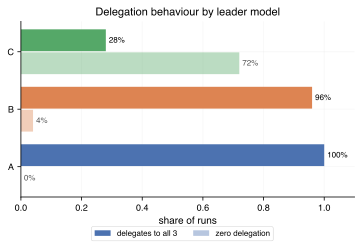

,n,full_rate,zero_rate,mean_coverage
leader,,,,
A,75,1.00,0.00,3.00
B,75,0.96,0.04,2.88
C,25,0.28,0.72,0.84


In [2]:
g = (runs.groupby("leader")
         .agg(n=("config", "size"),
              full_rate=("full_delegation", "mean"),
              zero_rate=("delegated", lambda s: 1 - s.mean()),
              mean_coverage=("coverage", "mean"))
         .reindex([l for l in ("A", "B", "C") if l in set(runs["leader"])]))

fig, ax = plt.subplots(figsize=FIG_COMPACT)
y = np.arange(len(g))
ax.barh(y + 0.2, g["full_rate"], height=0.38,
        color=[MODEL_COLORS[l] for l in g.index], label="delegates to all 3")
ax.barh(y - 0.2, g["zero_rate"], height=0.38,
        color=[MODEL_COLORS[l] for l in g.index], alpha=0.4, label="zero delegation")
ax.set_yticks(y)
ax.set_yticklabels(list(g.index), fontsize=9)
for yi, (fr, zr) in enumerate(zip(g["full_rate"], g["zero_rate"])):
    ax.text(fr + 0.01, yi + 0.2, f"{fr:.0%}", va="center", fontsize=8)
    ax.text(zr + 0.01, yi - 0.2, f"{zr:.0%}", va="center", fontsize=8, color=C_MUTED)
ax.set_xlim(0, 1.1)
ax.set_xlabel("share of runs")
ax.set_title(fig_title("Delegation behaviour by leader model"))
bottom = legend_below(fig, ax, ncol=2)
save_fig(fig, FIG_DIR / "delegation_by_leader.png", bottom=bottom)
plt.show()

g.assign(full_rate=g["full_rate"].round(3),
         zero_rate=g["zero_rate"].round(3),
         mean_coverage=g["mean_coverage"].round(3))


## 2. Delegation coverage by config

Mean number of experts actually consulted per review (0–3). All configs except the
references hold leader = B, so spread here is mostly paper-driven; All-C sits low
because the Llama leader usually self-reviews.

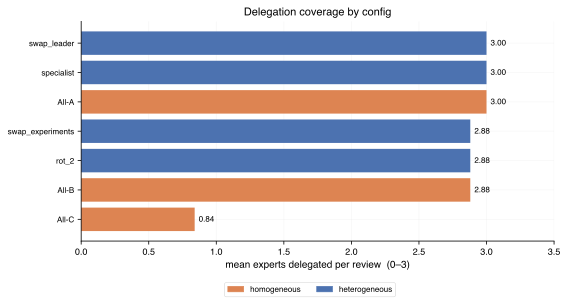

,mean_coverage,full_rate,homogeneous
config,,,
All-C,0.84,0.28,True
All-B,2.88,0.96,True
rot_2,2.88,0.96,False
swap_experiments,2.88,0.96,False
All-A,3.00,1.00,True
specialist,3.00,1.00,False
swap_leader,3.00,1.00,False


In [3]:
from matplotlib.patches import Patch

cov = (runs.groupby("config")
           .agg(mean_coverage=("coverage", "mean"),
                full_rate=("full_delegation", "mean"),
                homogeneous=("homogeneous", "first"))
           .sort_values("mean_coverage"))

fig, ax = plt.subplots(figsize=FIG_RANK)
colors = [C_REF if h else C_HET for h in cov["homogeneous"]]
y = np.arange(len(cov))
ax.barh(y, cov["mean_coverage"], color=colors)
ax.set_yticks(y)
ax.set_yticklabels(cov.index, fontsize=8)
for yi, v in enumerate(cov["mean_coverage"]):
    ax.text(v + 0.03, yi, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlim(0, 3.5)
ax.set_xlabel("mean experts delegated per review  (0–3)")
ax.set_title(fig_title("Delegation coverage by config"))
bottom = legend_below(fig, handles=[
    Patch(color=C_REF, label="homogeneous"),
    Patch(color=C_HET, label="heterogeneous"),
], labels=["homogeneous", "heterogeneous"], ncol=2)
save_fig(fig, FIG_DIR / "delegation_by_config.png", bottom=bottom)
plt.show()

cov.assign(mean_coverage=cov["mean_coverage"].round(3),
           full_rate=cov["full_rate"].round(3))


## 3. Paper-dependence

Delegation isn't purely a leader trait — it's `(leader × paper)`. The heatmap shows
coverage per config × paper; zero cells are flagged. Watch for papers where a
Mistral-leader config collapses to self-review (PLAN.md flags `6jxUsDAdAu`).

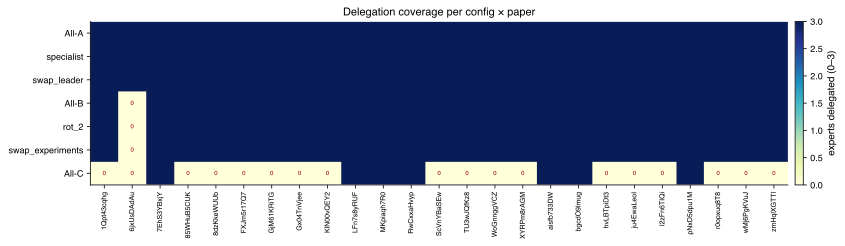

Non-Llama leader, zero-delegation runs:
          config      paper leader
           All-B 6jxUsDAdAu      B
           rot_2 6jxUsDAdAu      B
swap_experiments 6jxUsDAdAu      B


In [4]:
order = runs.groupby("config")["coverage"].mean().sort_values(ascending=False).index
pivot = runs.pivot(index="config", columns="paper", values="coverage").loc[order]

fig, ax = plt.subplots(figsize=(13, 3.8))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=3)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label("experts delegated (0–3)")
ax.set_title(fig_title("Delegation coverage per config × paper"))
ax.grid(False)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        if pivot.values[i, j] == 0:
            ax.text(j, i, "0", ha="center", va="center", fontsize=6, color="#900")
save_fig(fig, FIG_DIR / "delegation_heatmap.png", bottom=MARGIN_HEATMAP, top=0.88)
plt.show()

ab_zero = runs[(runs.leader != "C") & (~runs.delegated)]
print("Non-Llama leader, zero-delegation runs:")
print(ab_zero[["config", "paper", "leader"]].to_string(index=False) if len(ab_zero) else "  (none)")


## 4. Delegation vs win-rate (descriptive)

Does consulting more experts track a higher win-rate? Point colour = leader model.
**Heavy caveat:** the leader writes the final review either way, and delegation habit
is confounded with leader capability (All-A delegates fully *and* is strongest; All-C
self-reviews *and* is weakest). So this is association, not a causal "delegation helps"
claim — `comment_recall` on per-role outputs is the cleaner substance test.

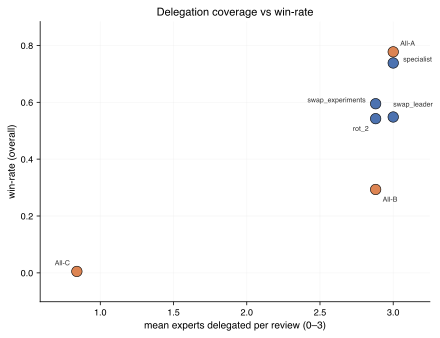

,config,mean_coverage,homogeneous,win_rate
0,All-A,3.00,True,0.778
4,specialist,3.00,False,0.738
5,swap_experiments,2.88,False,0.595
6,swap_leader,3.00,False,0.548
3,rot_2,2.88,False,0.542
1,All-B,2.88,True,0.293
2,All-C,0.84,True,0.005


In [5]:
wr_path = RESULTS_DIR / "win_rate.json"
if not wr_path.exists():
    print("win_rate.json missing — run eval/metrics/win_rate.py --run-set full first.")
else:
    per_config = json.loads(wr_path.read_text())["per_config"]
    m = (runs.groupby("config")
             .agg(mean_coverage=("coverage", "mean"),
                  homogeneous=("homogeneous", "first")))
    m["win_rate"] = [per_config[c]["overall"] for c in m.index]
    m = m.reset_index()

    fig, ax = plt.subplots(figsize=FIG_SCATTER)
    for _, row in m.iterrows():
        col = C_REF if row["homogeneous"] else C_HET
        ax.scatter(row["mean_coverage"], row["win_rate"], s=110,
                   color=col, edgecolor="k", linewidth=0.6, zorder=3)
    ax.set_xlabel("mean experts delegated per review (0–3)")
    ax.set_ylabel("win-rate (overall)")
    ax.set_title(fig_title("Delegation coverage vs win-rate"))
    pad_axes_for_labels(ax)
    annotate_configs(ax, m["mean_coverage"], m["win_rate"], m["config"])
    save_fig(fig, FIG_DIR / "delegation_vs_winrate.png", bottom=MARGIN_NO_LEGEND)
    plt.show()
    display(m.assign(mean_coverage=m["mean_coverage"].round(3),
                     win_rate=m["win_rate"].round(3)).sort_values("win_rate", ascending=False))


## 5. Takeaways (full, n=175 runs)

_Observed from the current run — re-check after any regeneration._

1. **Delegation is a leader-model trait.** qwen (A) delegates to all three experts on
   100% of runs (75/75), Mistral (B) on 96% (72/75), Llama (C) on just 28% (7/25) —
   18/25 All-C runs are self-reviews. This extends the "C can't lead" rationale: C
   *can* be prompted to lead but mostly declines to delegate.
2. **It's `(leader × paper)`, not leader alone.** All three Mistral-leader
   zero-delegation runs land on the **same paper `6jxUsDAdAu`** (All-B, rot_2,
   swap_experiments) — a reproducible behaviour, not noise.
3. **Coverage tracks win-rate, but it's confounded.** All-A (full coverage, strongest)
   tops the chart; All-C (near-zero coverage, weakest) sits at the bottom — but the
   leader writes the final review regardless, so this is capability association, not
   evidence that delegating *causes* better reviews.
4. **Implication for other metrics.** Zero-delegation runs contribute no per-role
   expert text, so they legitimately supply no diversity / comment-recall signal —
   keep them as valid reviews but read substance metrics with that in mind.